# Garbage Classification with ResNet50
## Deep Learning Project

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)

if torch.cuda.is_available():
    print("GPU adı:", torch.cuda.get_device_name(0))
    print("Toplam GPU Belleği (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
    print("CUDA Versiyonu:", torch.version.cuda)


Kullanılan cihaz: cuda
GPU adı: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Toplam GPU Belleği (GB): 4.0
CUDA Versiyonu: 11.8


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
data_dir = r"C:\data\garbage_224"



In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # 👈 KRİTİK SATIR
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # 👈 KRİTİK SATIR
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [5]:
from torchvision import datasets
from torch.utils.data import DataLoader
import os

train_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "train"),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(data_dir, "test"),
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Sınıf sayısı:", num_classes)
print("Sınıflar:", class_names)



Sınıf sayısı: 10
Sınıflar: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [6]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)

# Backbone'u dondur
for param in model.parameters():
    param.requires_grad = False

# Son katmanı aç
model.fc = nn.Linear(model.fc.in_features, num_classes)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)


In [7]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),  # sadece fc
    lr=0.0001
)


In [8]:
num_epochs = 20
scaler = torch.amp.GradScaler("cuda")



In [9]:
for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.2f}%")


Epoch [1/20] Loss: 1.2612 | Train Acc: 64.96%
Epoch [2/20] Loss: 0.6901 | Train Acc: 83.44%
Epoch [3/20] Loss: 0.5457 | Train Acc: 85.90%
Epoch [4/20] Loss: 0.4770 | Train Acc: 86.81%
Epoch [5/20] Loss: 0.4386 | Train Acc: 87.47%
Epoch [6/20] Loss: 0.4119 | Train Acc: 87.74%
Epoch [7/20] Loss: 0.3951 | Train Acc: 88.23%
Epoch [8/20] Loss: 0.3779 | Train Acc: 88.54%
Epoch [9/20] Loss: 0.3647 | Train Acc: 88.95%
Epoch [10/20] Loss: 0.3529 | Train Acc: 89.04%
Epoch [11/20] Loss: 0.3497 | Train Acc: 89.34%
Epoch [12/20] Loss: 0.3388 | Train Acc: 89.50%
Epoch [13/20] Loss: 0.3360 | Train Acc: 89.69%
Epoch [14/20] Loss: 0.3263 | Train Acc: 89.73%
Epoch [15/20] Loss: 0.3248 | Train Acc: 89.44%
Epoch [16/20] Loss: 0.3228 | Train Acc: 90.01%
Epoch [17/20] Loss: 0.3147 | Train Acc: 90.01%
Epoch [18/20] Loss: 0.3121 | Train Acc: 90.08%
Epoch [19/20] Loss: 0.3022 | Train Acc: 90.33%
Epoch [20/20] Loss: 0.2971 | Train Acc: 90.40%


In [10]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
print("Test seti tahminleri tamamlandı.")
print("Toplam örnek sayısı:", len(all_labels))

Test seti tahminleri tamamlandı.
Toplam örnek sayısı: 2974


In [11]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))


              precision    recall  f1-score   support

     battery       0.91      0.95      0.93       143
  biological       0.96      0.95      0.96       151
   cardboard       0.93      0.84      0.88       275
     clothes       0.99      0.98      0.98       800
       glass       0.87      0.95      0.91       460
       metal       0.73      0.86      0.79       153
       paper       0.92      0.84      0.88       252
     plastic       0.94      0.78      0.85       299
       shoes       0.91      0.98      0.94       298
       trash       0.75      0.81      0.78       143

    accuracy                           0.91      2974
   macro avg       0.89      0.89      0.89      2974
weighted avg       0.92      0.91      0.91      2974



In [12]:
train_losses = []
train_accuracies = []


In [14]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f}, Acc={epoch_acc:.2f}%")


Epoch 1: Loss=0.2997, Acc=90.52%
Epoch 2: Loss=0.2917, Acc=90.63%
Epoch 3: Loss=0.2983, Acc=90.06%


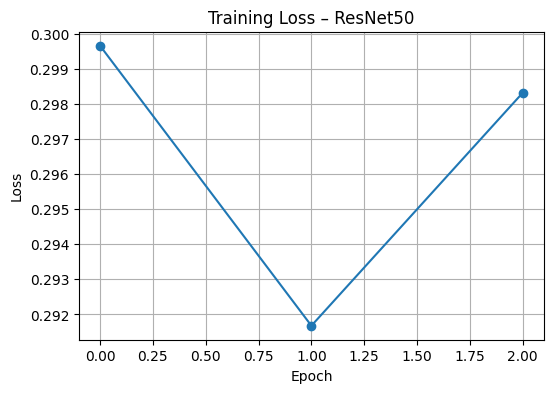

In [15]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, marker='o')
plt.title("Training Loss – ResNet50")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


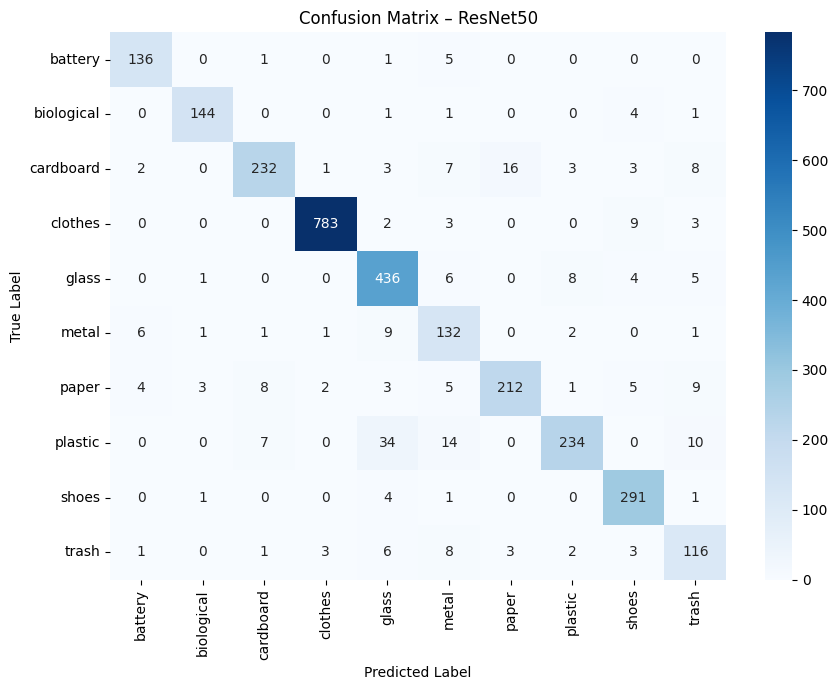

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – ResNet50")
plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True
)

df = pd.DataFrame(report).transpose()
df = df.iloc[:-3]  # accuracy, avg satırlarını çıkar


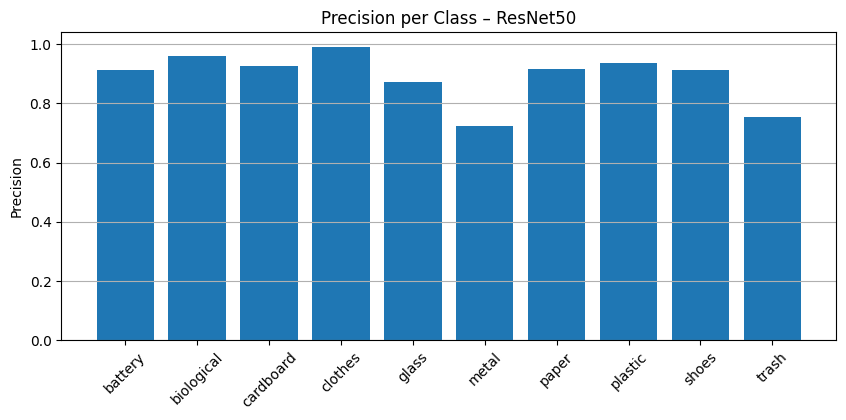

In [18]:
plt.figure(figsize=(10,4))
plt.bar(df.index, df["precision"])
plt.xticks(rotation=45)
plt.title("Precision per Class – ResNet50")
plt.ylabel("Precision")
plt.grid(axis='y')
plt.show()


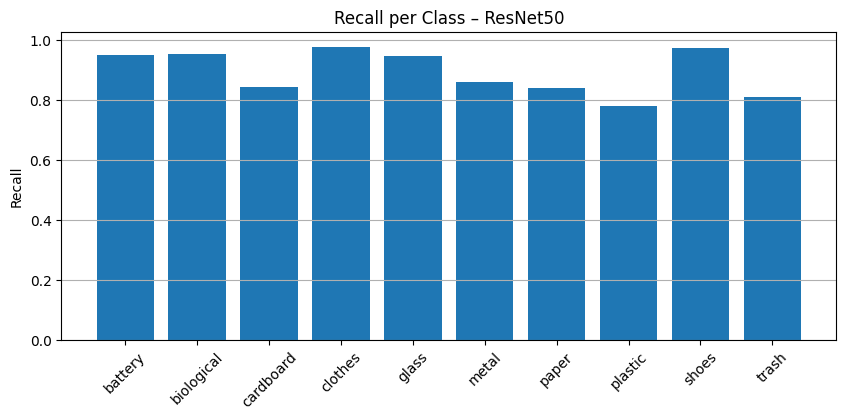

In [19]:
plt.figure(figsize=(10,4))
plt.bar(df.index, df["recall"])
plt.xticks(rotation=45)
plt.title("Recall per Class – ResNet50")
plt.ylabel("Recall")
plt.grid(axis='y')
plt.show()


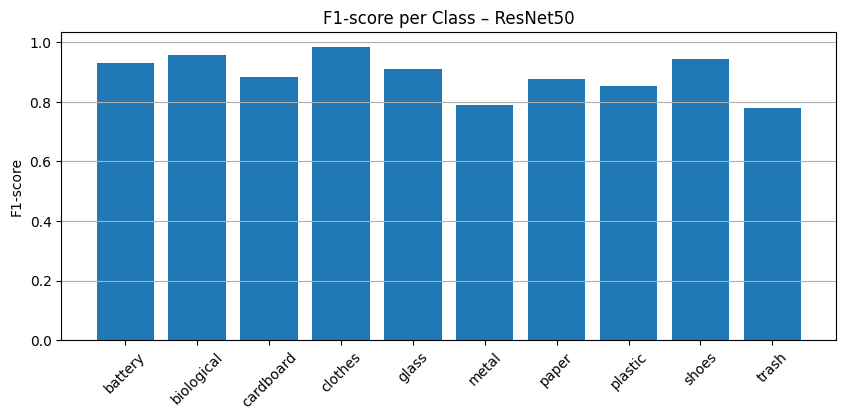

In [20]:
plt.figure(figsize=(10,4))
plt.bar(df.index, df["f1-score"])
plt.xticks(rotation=45)
plt.title("F1-score per Class – ResNet50")
plt.ylabel("F1-score")
plt.grid(axis='y')
plt.show()


In [21]:
df.sort_values("f1-score", ascending=False)[["f1-score"]]


,f1-score
clothes,0.984906
biological,0.956811
shoes,0.943274
battery,0.931507
glass,0.909281
cardboard,0.883810
paper,0.877847
plastic,0.852459
metal,0.788060
trash,0.781145


In [22]:
confusions = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            confusions.append((
                class_names[i],
                class_names[j],
                cm[i, j]
            ))

conf_df = pd.DataFrame(confusions, columns=["True", "Predicted", "Count"])
conf_df.sort_values("Count", ascending=False).head(10)


,True,Predicted,Count
67,plastic,glass,34
23,cardboard,paper,16
68,plastic,metal,14
71,plastic,trash,10
34,clothes,shoes,9
62,paper,trash,9
49,metal,glass,9
42,glass,plastic,8
26,cardboard,trash,8
56,paper,cardboard,8


In [23]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)


In [24]:
n_classes = len(class_names)
y_test_bin = label_binarize(all_labels, classes=range(n_classes))


In [25]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
roc_auc["macro"] = auc(all_fpr, mean_tpr)


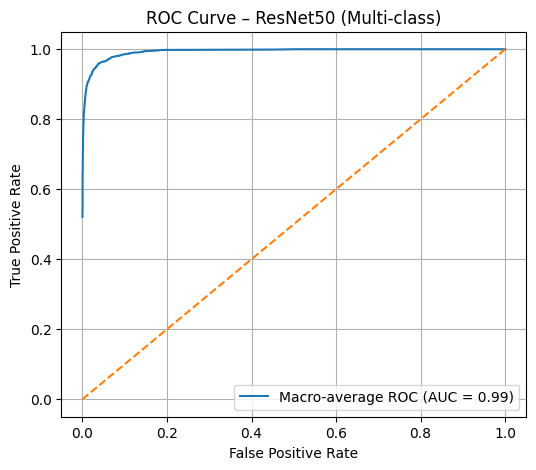

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – ResNet50 (Multi-class)")
plt.legend()
plt.grid()
plt.show()


In [27]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision = {}
recall = {}
ap = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i], all_probs[:, i]
    )
    ap[i] = average_precision_score(y_test_bin[:, i], all_probs[:, i])

mean_ap = np.mean(list(ap.values()))


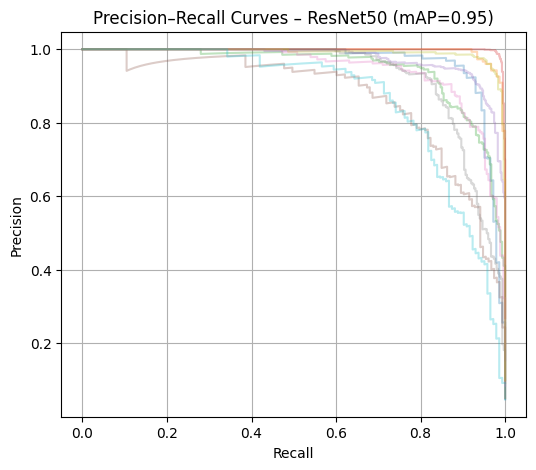

In [28]:
plt.figure(figsize=(6,5))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], alpha=0.3)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curves – ResNet50 (mAP={mean_ap:.2f})")
plt.grid()
plt.show()


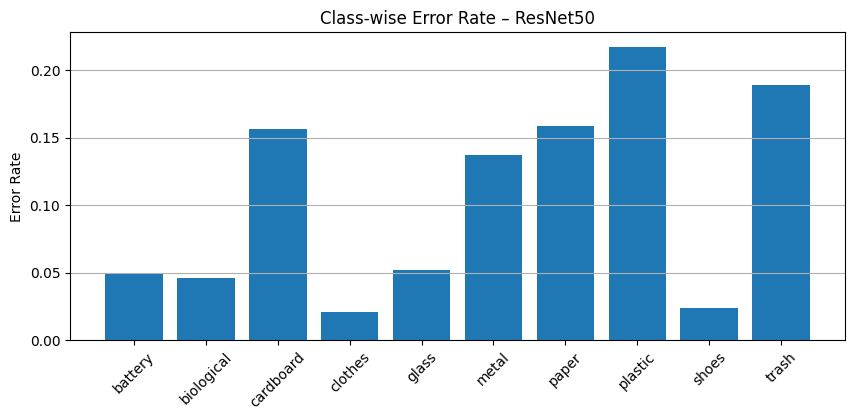

In [29]:
error_rate = 1 - np.diag(cm) / cm.sum(axis=1)

plt.figure(figsize=(10,4))
plt.bar(class_names, error_rate)
plt.xticks(rotation=45)
plt.ylabel("Error Rate")
plt.title("Class-wise Error Rate – ResNet50")
plt.grid(axis="y")
plt.show()


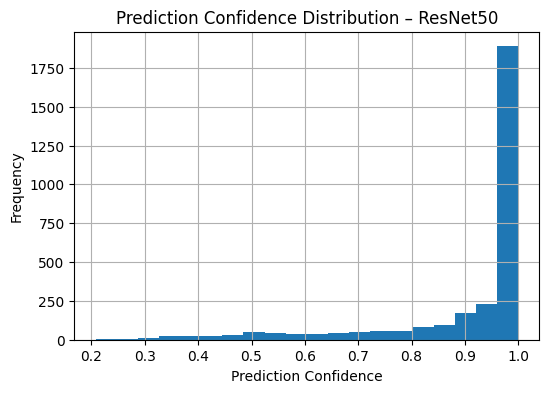

In [30]:
confidences = np.max(all_probs, axis=1)

plt.figure(figsize=(6,4))
plt.hist(confidences, bins=20)
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution – ResNet50")
plt.grid()
plt.show()


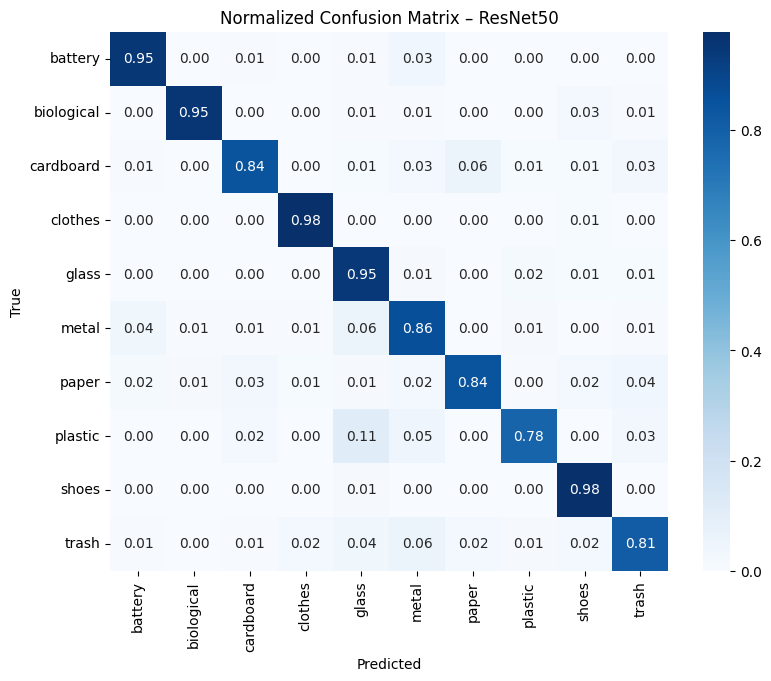

In [31]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, None]

plt.figure(figsize=(9,7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Normalized Confusion Matrix – ResNet50")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [32]:
top3_correct = 0
top5_correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, top5 = outputs.topk(5, dim=1)

        total += labels.size(0)
        top3_correct += sum(labels[i] in top5[i, :3] for i in range(len(labels)))
        top5_correct += sum(labels[i] in top5[i] for i in range(len(labels)))

print("Top-3 Accuracy:", top3_correct / total)
print("Top-5 Accuracy:", top5_correct / total)


Top-3 Accuracy: 0.9818426361802286
Top-5 Accuracy: 0.9942837928715534


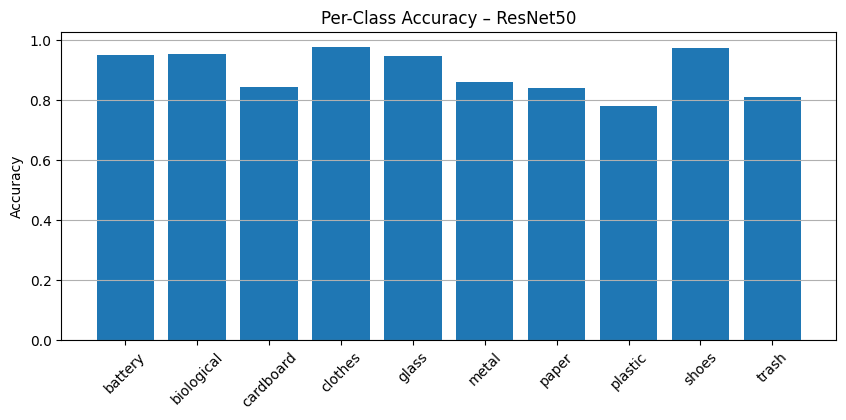

In [34]:
class_acc = np.diag(cm) / cm.sum(axis=1)

plt.figure(figsize=(10,4))
plt.bar(class_names, class_acc)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy – ResNet50")
plt.grid(axis="y")
plt.show()


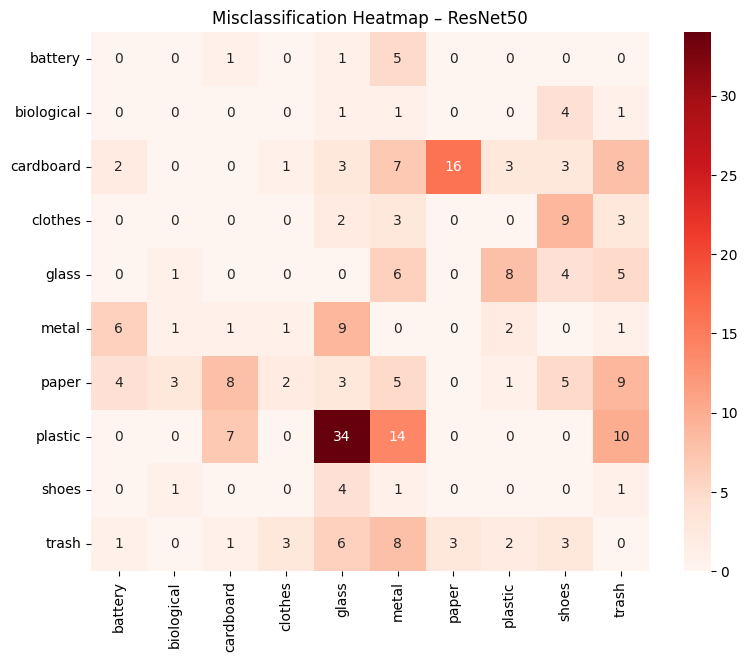

In [35]:
mis_cm = cm.copy()
np.fill_diagonal(mis_cm, 0)

plt.figure(figsize=(9,7))
sns.heatmap(
    mis_cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Misclassification Heatmap – ResNet50")
plt.show()


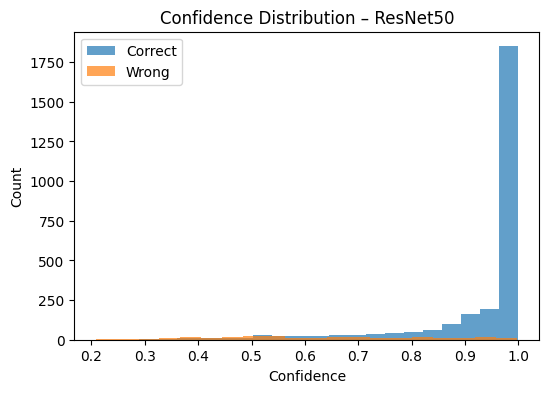

In [36]:
correct_mask = (np.array(all_preds) == np.array(all_labels))

plt.figure(figsize=(6,4))
plt.hist(confidences[correct_mask], bins=20, alpha=0.7, label="Correct")
plt.hist(confidences[~correct_mask], bins=20, alpha=0.7, label="Wrong")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.title("Confidence Distribution – ResNet50")
plt.legend()
plt.show()


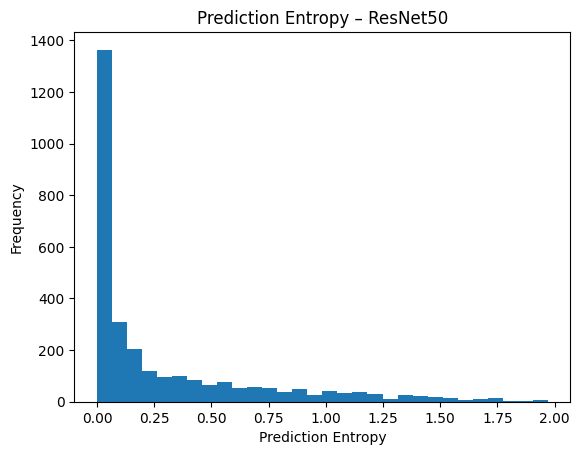

In [37]:
entropy = -np.sum(all_probs * np.log(all_probs + 1e-9), axis=1)

plt.hist(entropy, bins=30)
plt.xlabel("Prediction Entropy")
plt.ylabel("Frequency")
plt.title("Prediction Entropy – ResNet50")
plt.show()


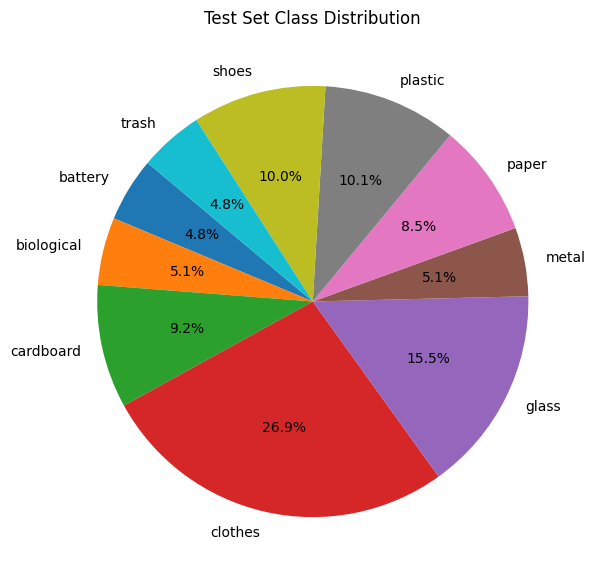

In [38]:
import matplotlib.pyplot as plt
import numpy as np

class_counts = np.bincount(all_labels)

plt.figure(figsize=(7,7))
plt.pie(
    class_counts,
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Test Set Class Distribution")
plt.show()


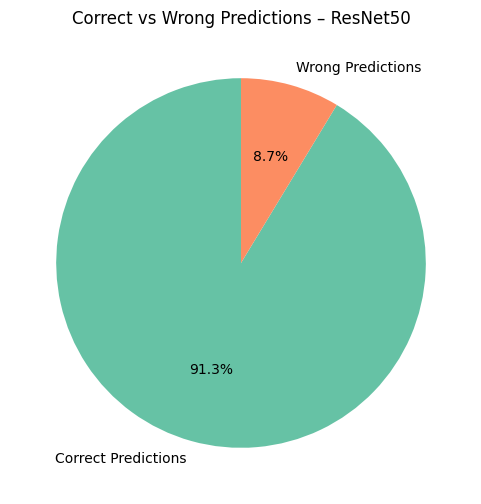

In [39]:
correct = np.sum(np.array(all_preds) == np.array(all_labels))
wrong = np.sum(np.array(all_preds) != np.array(all_labels))

plt.figure(figsize=(6,6))
plt.pie(
    [correct, wrong],
    labels=["Correct Predictions", "Wrong Predictions"],
    autopct='%1.1f%%',
    colors=["#66c2a5", "#fc8d62"],
    startangle=90
)
plt.title("Correct vs Wrong Predictions – ResNet50")
plt.show()


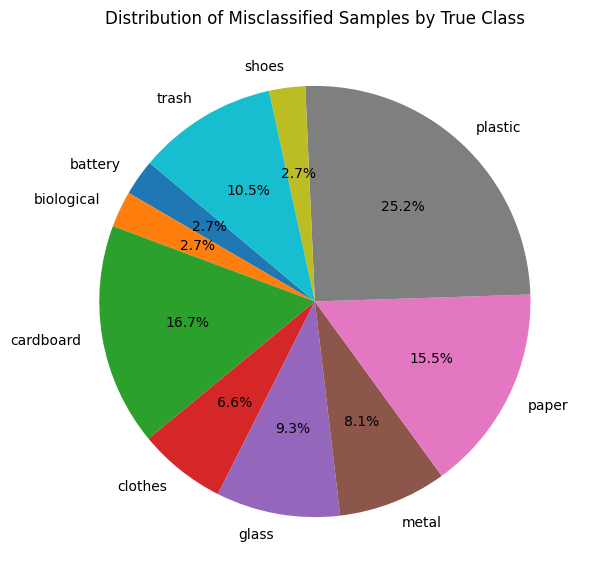

In [40]:
wrong_indices = np.where(np.array(all_preds) != np.array(all_labels))[0]
wrong_labels = np.array(all_labels)[wrong_indices]

wrong_counts = np.bincount(wrong_labels)

plt.figure(figsize=(7,7))
plt.pie(
    wrong_counts,
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Distribution of Misclassified Samples by True Class")
plt.show()


In [45]:
import os

project_path = r"C:\Users\Lenovo\Desktop\Garbage_Classification_Project"
print(os.listdir(project_path))


['FEYZA_KORKMAZ_23040101061_GreenMind_InceptionV3.ipynb', 'FEYZA_KORKMAZ_23040101061_GreenMind_ResNet50.ipynb', 'garbage-dataset', 'garbage-dataset-split', 'InceptionV3_Genel_Metrikler.csv', 'model_comparison_results.csv']


In [46]:
import torch

save_path = r"C:\Users\Lenovo\Desktop\Garbage_Classification_Project\resnet50_best.pth"

torch.save(model.state_dict(), save_path)

print("✅ Model başarıyla kaydedildi:", save_path)


✅ Model başarıyla kaydedildi: C:\Users\Lenovo\Desktop\Garbage_Classification_Project\resnet50_best.pth


In [47]:
model.load_state_dict(torch.load(r"C:\Users\Lenovo\Desktop\Garbage_Classification_Project\resnet50_best.pth",
                                 map_location=device,
                                 weights_only=True))
model.eval()
print("Model yüklendi ✅")


Model yüklendi ✅


In [49]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds)

class_accuracy = []
for i in range(len(class_names)):
    idx = [j for j in range(len(all_labels)) if all_labels[j] == i]
    correct = sum([1 for j in idx if all_preds[j] == all_labels[j]])
    acc = correct / len(idx) * 100
    class_accuracy.append(acc)

df_classwise = pd.DataFrame({
    "Class": class_names,
    "Precision (%)": precision * 100,
    "Recall (%)": recall * 100,
    "F1-Score (%)": f1 * 100,
    "Accuracy (%)": class_accuracy
})

df_classwise


,Class,Precision (%),Recall (%),F1-Score (%),Accuracy (%)
0,battery,91.275168,95.104895,93.150685,95.104895
1,biological,96.000000,95.364238,95.681063,95.364238
2,cardboard,92.800000,84.363636,88.380952,84.363636
3,clothes,99.113924,97.875000,98.490566,97.875000
4,glass,87.374749,94.782609,90.928050,94.782609
5,metal,72.527473,86.274510,78.805970,86.274510
6,paper,91.774892,84.126984,87.784679,84.126984
7,plastic,93.600000,78.260870,85.245902,78.260870
8,shoes,91.222571,97.651007,94.327391,97.651007
9,trash,75.324675,81.118881,78.114478,81.118881


In [50]:
df_classwise.to_csv("ResNet50_Classwise_Performance.csv", index=False)


In [51]:
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted'
)

overall_accuracy = accuracy_score(all_labels, all_preds)

df_overall = pd.DataFrame({
    "Model": ["ResNet50"],
    "Precision (%)": [overall_precision * 100],
    "Recall (%)": [overall_recall * 100],
    "F1-Score (%)": [overall_f1 * 100],
    "Accuracy (%)": [overall_accuracy * 100]
})

df_overall


,Model,Precision (%),Recall (%),F1-Score (%),Accuracy (%)
0,ResNet50,91.700741,91.324815,91.33827,91.324815


In [52]:
df_overall.to_csv("ResNet50_Overall_Performance.csv", index=False)


In [60]:
import pandas as pd

data = {
    "Model": ["Base CNN", "InceptionV3", "ResNet50"],
    "Precision (%)": [48.865545, 89.00, 91.700741],
    "Recall (%)":    [69.903895, 89.40, 91.324815],
    "F1-Score (%)":  [57.521395, 89.10, 91.33827],
    "Accuracy (%)":  [69.903895, 91.36, 91.324815]
}

df_models = pd.DataFrame(data)

styled_table = (
    df_models.style
    .background_gradient(cmap="Oranges", subset=["Precision (%)","Recall (%)","F1-Score (%)","Accuracy (%)"])
    
    .highlight_max(
        subset=["Precision (%)","Recall (%)","F1-Score (%)","Accuracy (%)"],
        color="#D35400" 
    )
    
    .apply(lambda row: ['font-weight: bold' if row.name == df_models["Accuracy (%)"].idxmax() else '' for _ in row], axis=1)
    
    .set_properties(**{
        'text-align': 'center',
        'font-size': '12pt'
    })
    
    .set_caption("Model Performance Comparison")
)

styled_table


,Model,Precision (%),Recall (%),F1-Score (%),Accuracy (%)
0,Base CNN,48.865545,69.903895,57.521395,69.903895
1,InceptionV3,89.000000,89.400000,89.100000,91.360000
2,ResNet50,91.700741,91.324815,91.338270,91.324815


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].


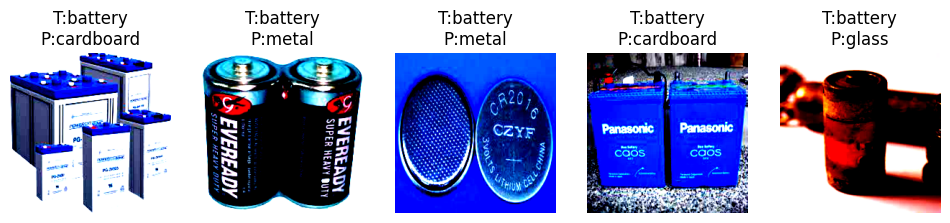

In [26]:
wrong_indices = np.where(np.array(all_preds) != np.array(all_labels))[0][:5]

plt.figure(figsize=(12,3))
for i, idx in enumerate(wrong_indices):
    img, label = test_dataset[idx]
    plt.subplot(1,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"T:{class_names[label]}\nP:{class_names[all_preds[idx]]}")
    plt.axis("off")
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


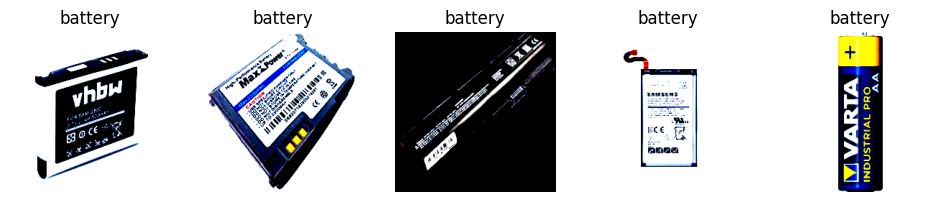

In [27]:
correct_indices = np.where(np.array(all_preds) == np.array(all_labels))[0][:5]

plt.figure(figsize=(12,3))
for i, idx in enumerate(correct_indices):
    img, label = test_dataset[idx]
    plt.subplot(1,5,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[label])
    plt.axis("off")
plt.show()


In [45]:
import numpy as np
import matplotlib.pyplot as plt

all_preds_np = np.array(all_preds)
all_labels_np = np.array(all_labels)

wrong_indices = np.where(all_preds_np != all_labels_np)[0]
correct_indices = np.where(all_preds_np == all_labels_np)[0]

print("Yanlış sınıflandırılan örnek sayısı:", len(wrong_indices))
print("Doğru sınıflandırılan örnek sayısı:", len(correct_indices))


Yanlış sınıflandırılan örnek sayısı: 266
Doğru sınıflandırılan örnek sayısı: 2708


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping inpu

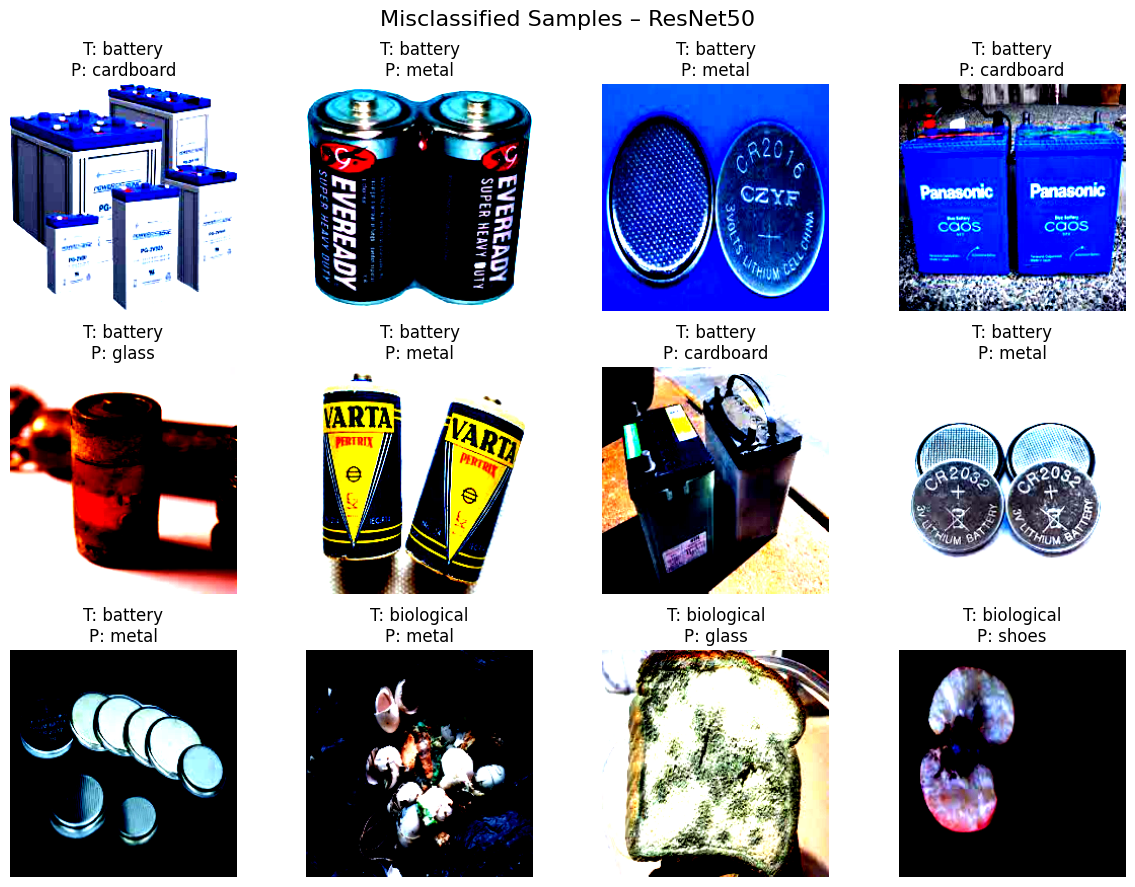

In [46]:
num_samples = 12

plt.figure(figsize=(12,9))
for i, idx in enumerate(wrong_indices[:num_samples]):
    img, label = test_dataset[idx]
    plt.subplot(3,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"T: {class_names[label]}\nP: {class_names[all_preds_np[idx]]}")
    plt.axis("off")

plt.suptitle("Misclassified Samples – ResNet50", fontsize=16)
plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data t

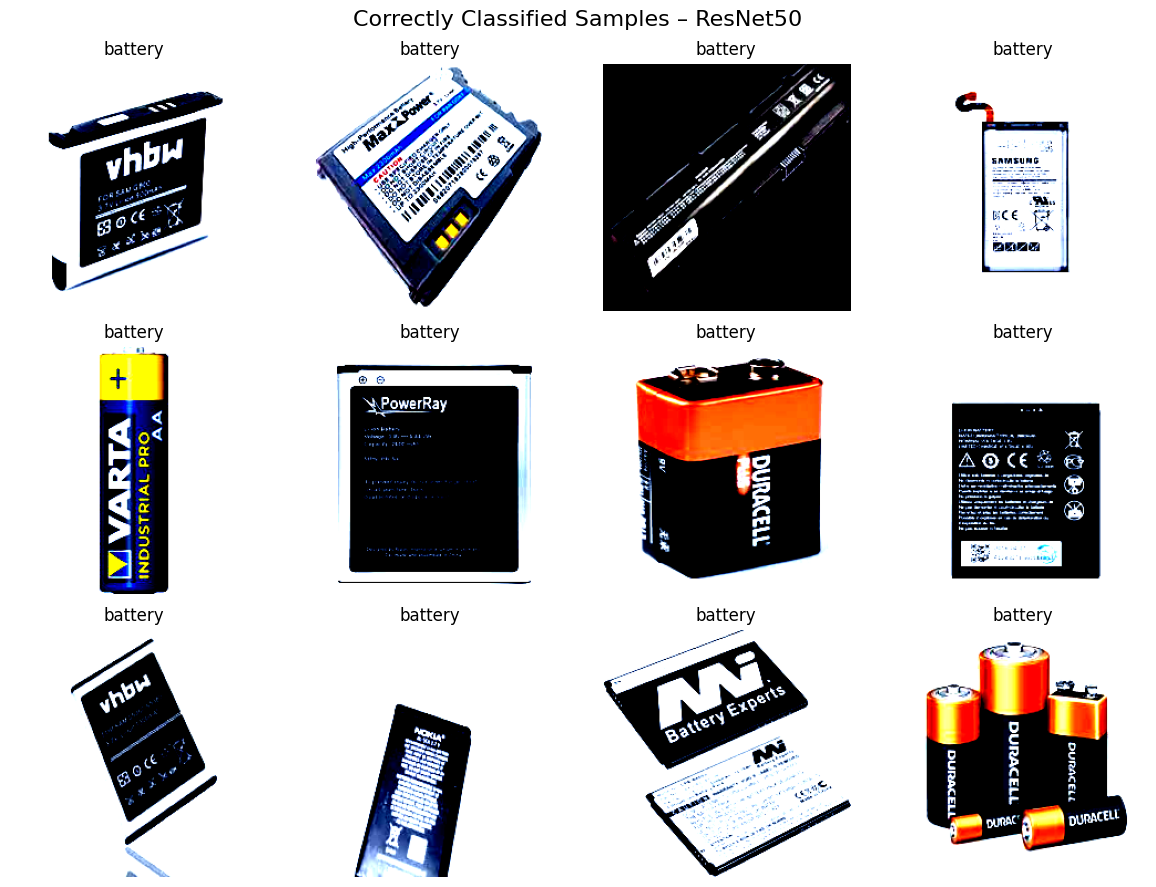

In [47]:
num_samples = 12

plt.figure(figsize=(12,9))
for i, idx in enumerate(correct_indices[:num_samples]):
    img, label = test_dataset[idx]
    plt.subplot(3,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"{class_names[label]}")
    plt.axis("off")

plt.suptitle("Correctly Classified Samples – ResNet50", fontsize=16)
plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7411594..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.5702832].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping in

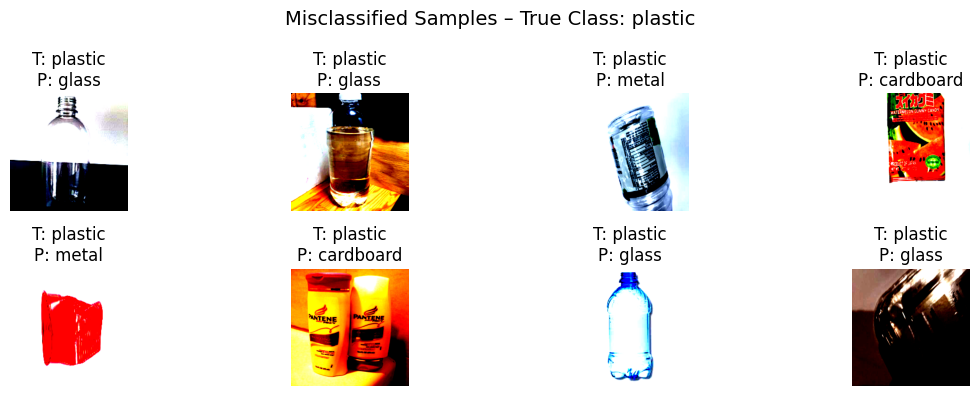

In [48]:
target_class = "plastic"
class_id = class_names.index(target_class)

class_wrong = [
    idx for idx in wrong_indices
    if all_labels_np[idx] == class_id
][:8]

plt.figure(figsize=(12,4))
for i, idx in enumerate(class_wrong):
    img, label = test_dataset[idx]
    plt.subplot(2,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(f"T: {class_names[label]}\nP: {class_names[all_preds_np[idx]]}")
    plt.axis("off")

plt.suptitle(f"Misclassified Samples – True Class: {target_class}", fontsize=14)
plt.tight_layout()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6680672..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.30268008..2.4308496].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7240347..2.186841].
Clipping inpu

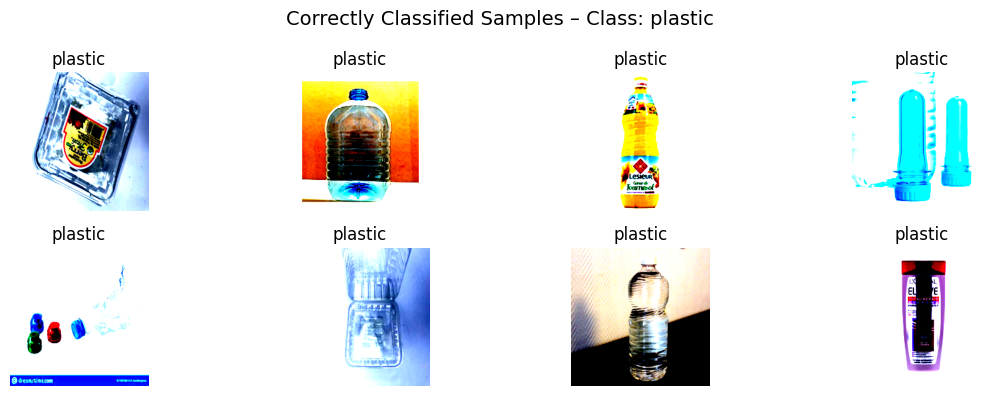

In [49]:
class_correct = [
    idx for idx in correct_indices
    if all_labels_np[idx] == class_id
][:8]

plt.figure(figsize=(12,4))
for i, idx in enumerate(class_correct):
    img, label = test_dataset[idx]
    plt.subplot(2,4,i+1)
    plt.imshow(img.permute(1,2,0))
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle(f"Correctly Classified Samples – Class: {target_class}", fontsize=14)
plt.tight_layout()
plt.show()
